In [1]:
pip install -U langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.9/160.9 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.0.9
    Uninstalling langgraph-1.0.9:
      Successfully uninstalled langgraph-1.0.9


In [2]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict

class State(TypedDict):
    messages: list[AnyMessage]
    extra_field: int

Update State

In [3]:
from langchain.messages import AIMessage

def node(state: State):
    messages = state["messages"]
    new_message = AIMessage("Hello!")
    return {"messages": messages + [new_message], "extra_field": 10}

Build a graph using this node

In [4]:
from langgraph.graph import StateGraph

builder = StateGraph(State)
builder.add_node(node)
builder.set_entry_point("node")
graph = builder.compile()

Visualize the graph

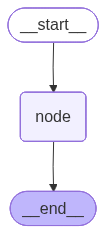

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
from langchain.messages import HumanMessage

result = graph.invoke({"messages": [HumanMessage("Hi")]})
result

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 10}

In [7]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

Hello!


Process state updates with reducers

In [8]:
from typing_extensions import Annotated

def add(left, right):
    """Can also import `add` from the `operator` built-in."""
    return left + right

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add]
    extra_field: int

In [9]:
def node(state: State):
    new_message = AIMessage("Hello!")
    return {"messages": [new_message], "extra_field": 10}

In [10]:
from langgraph.graph import START

graph = StateGraph(State).add_node(node).add_edge(START, "node").compile()

result = graph.invoke({"messages": [HumanMessage("Hi")]})

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

Hello!


MessagesState

In [11]:
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    extra_field: int

def node(state: State):
    new_message = AIMessage("Hello!")
    return {"messages": [new_message], "extra_field": 10}

graph = StateGraph(State).add_node(node).set_entry_point("node").compile()

In [12]:
input_message = {"role": "user", "content": "Hi"}

result = graph.invoke({"messages": [input_message]})

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

Hello!


In [13]:
from langgraph.graph import MessagesState

class State(MessagesState):
    extra_field: int

Overwrite

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Overwrite
from typing_extensions import Annotated, TypedDict
import operator

class State(TypedDict):
    messages: Annotated[list, operator.add]

def add_message(state: State):
    return {"messages": ["first message"]}

def replace_messages(state: State):
    # Bypass the reducer and replace the entire messages list
    return {"messages": Overwrite(["replacement message"])}

builder = StateGraph(State)
builder.add_node("add_message", add_message)
builder.add_node("replace_messages", replace_messages)
builder.add_edge(START, "add_message")
builder.add_edge("add_message", "replace_messages")
builder.add_edge("replace_messages", END)

graph = builder.compile()

result = graph.invoke({"messages": ["initial"]})
print(result["messages"])

['replacement message']


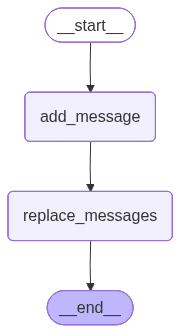

In [2]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

Define input and output schemas

In [3]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

# Define the schema for the input
class InputState(TypedDict):
    question: str

# Define the schema for the output
class OutputState(TypedDict):
    answer: str

# Define the overall schema, combining both input and output
class OverallState(InputState, OutputState):
    pass

# Define the node that processes the input and generates an answer
def answer_node(state: InputState):
    # Example answer and an extra key
    return {"answer": "bye", "question": state["question"]}

# Build the graph with input and output schemas specified
builder = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
builder.add_node(answer_node)  # Add the answer node
builder.add_edge(START, "answer_node")  # Define the starting edge
builder.add_edge("answer_node", END)  # Define the ending edge
graph = builder.compile()  # Compile the graph

# Invoke the graph with an input and print the result
print(graph.invoke({"question": "hi"}))

{'answer': 'bye'}


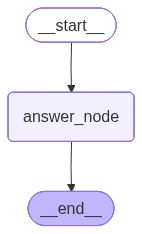

In [4]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

Pass private state between nodes

In [5]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

# The overall state of the graph (this is the public state shared across nodes)
class OverallState(TypedDict):
    a: str

# Output from node_1 contains private data that is not part of the overall state
class Node1Output(TypedDict):
    private_data: str

# The private data is only shared between node_1 and node_2
def node_1(state: OverallState) -> Node1Output:
    output = {"private_data": "set by node_1"}
    print(f"Entered node `node_1`:\n\tInput: {state}.\n\tReturned: {output}")
    return output

# Node 2 input only requests the private data available after node_1
class Node2Input(TypedDict):
    private_data: str

def node_2(state: Node2Input) -> OverallState:
    output = {"a": "set by node_2"}
    print(f"Entered node `node_2`:\n\tInput: {state}.\n\tReturned: {output}")
    return output

# Node 3 only has access to the overall state (no access to private data from node_1)
def node_3(state: OverallState) -> OverallState:
    output = {"a": "set by node_3"}
    print(f"Entered node `node_3`:\n\tInput: {state}.\n\tReturned: {output}")
    return output

# Connect nodes in a sequence
# node_2 accepts private data from node_1, whereas
# node_3 does not see the private data.
builder = StateGraph(OverallState).add_sequence([node_1, node_2, node_3])
builder.add_edge(START, "node_1")
graph = builder.compile()

# Invoke the graph with the initial state
response = graph.invoke(
    {
        "a": "set at start",
    }
)

print()
print(f"Output of graph invocation: {response}")

Entered node `node_1`:
	Input: {'a': 'set at start'}.
	Returned: {'private_data': 'set by node_1'}
Entered node `node_2`:
	Input: {'private_data': 'set by node_1'}.
	Returned: {'a': 'set by node_2'}
Entered node `node_3`:
	Input: {'a': 'set by node_2'}.
	Returned: {'a': 'set by node_3'}

Output of graph invocation: {'a': 'set by node_3'}


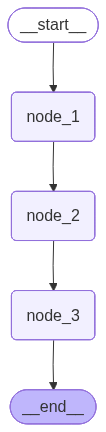

In [6]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

pydantic models for graph state

In [7]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from pydantic import BaseModel

# The overall state of the graph (this is the public state shared across nodes)
class OverallState(BaseModel):
    a: str

def node(state: OverallState):
    return {"a": "goodbye"}

# Build the state graph
builder = StateGraph(OverallState)
builder.add_node(node)  # node_1 is the first node
builder.add_edge(START, "node")  # Start the graph with node_1
builder.add_edge("node", END)  # End the graph after node_1
graph = builder.compile()

# Test the graph with a valid input
graph.invoke({"a": "hello"})

{'a': 'goodbye'}

In [8]:
try:
    graph.invoke({"a": 123})  # Should be a string
except Exception as e:
    print("An exception was raised because `a` is an integer rather than a string.")
    print(e)

An exception was raised because `a` is an integer rather than a string.
1 validation error for OverallState
a
  Input should be a valid string [type=string_type, input_value=123, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type


Add runtime configuration

In [12]:
from langgraph.graph import END, StateGraph, START
from langgraph.runtime import Runtime
from typing_extensions import TypedDict
from langgraph.types import RetryPolicy # Import RetryPolicy

# 1. Specify config schema
class ContextSchema(TypedDict):
    my_runtime_value: str

# 2. Define a graph that accesses the config in a node
class State(TypedDict):
    my_state_value: str

def node(state: State, runtime: Runtime[ContextSchema]):
    if runtime.context["my_runtime_value"] == "a":
        return {"my_state_value": 1}
    elif runtime.context["my_runtime_value"] == "b":
        return {"my_state_value": 2}
    else:
        raise ValueError("Unknown values.")

builder = StateGraph(State, context_schema=ContextSchema)
# Add the node with the retry policy here, before compilation
builder.add_node("node", node, retry_policy=RetryPolicy()) # Apply retry policy directly
builder.add_edge(START, "node")
builder.add_edge("node", END)

graph = builder.compile()

# 3. Pass in configuration at runtime:
print(graph.invoke({}, context={"my_runtime_value": "a"}))
print(graph.invoke({}, context={"my_runtime_value": "b"}))

{'my_state_value': 1}
{'my_state_value': 2}


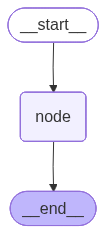

In [19]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Add retry policies

In [13]:
from langgraph.types import RetryPolicy

# Assuming `node` function and `builder` are defined in previous cells
# from the 'Add runtime configuration' section (cell p31sWKnzQQhc).
# Replacing `node_function` with the previously defined `node` function for demonstration.
builder.add_node(
    "node_with_retry",
    node,
    retry_policy=RetryPolicy(),
)

Create a sequence of steps

In [25]:
from langgraph.graph import START, StateGraph
from typing_extensions import TypedDict, Annotated
from langchain.messages import AnyMessage
import operator

# Define the State class (e.g., from cell lz53NHs7Zq3y for context)
class State(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    extra_field: int

# Define placeholder functions for the steps
def step_1(state):
    print("Executing step 1")
    return state

def step_2(state):
    print("Executing step 2")
    return state

def step_3(state):
    print("Executing step 3")
    return state

builder = StateGraph(State)

# Add nodes
builder.add_node(step_1)
builder.add_node(step_2)
builder.add_node(step_3)

# Add edges
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")

In [27]:
builder = StateGraph(State).add_sequence([step_1, step_2, step_3])
builder.add_edge(START, "step_1")

Create branches

In [29]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f'Adding "A" to {state["aggregate"]}')
    return {"aggregate": ["A"]}

def b(state: State):
    print(f'Adding "B" to {state["aggregate"]}')
    return {"aggregate": ["B"]}

def c(state: State):
    print(f'Adding "C" to {state["aggregate"]}')
    return {"aggregate": ["C"]}

def d(state: State):
    print(f'Adding "D" to {state["aggregate"]}')
    return {"aggregate": ["D"]}

builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

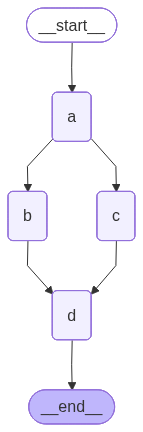

In [30]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

with reducer u can see values added

In [33]:
graph.invoke({"aggregate": []}, {"configurable": {"thread_id": "foo"}})

Adding "A" to []
Adding "B" to ['A']
Adding "C" to ['A']
Adding "D" to ['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'D']}

Defer node execution:Delay execution

In [34]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    # The operator.add reducer fn makes this append-only
    aggregate: Annotated[list, operator.add]

def a(state: State):
    print(f'Adding "A" to {state["aggregate"]}')
    return {"aggregate": ["A"]}

def b(state: State):
    print(f'Adding "B" to {state["aggregate"]}')
    return {"aggregate": ["B"]}

def b_2(state: State):
    print(f'Adding "B_2" to {state["aggregate"]}')
    return {"aggregate": ["B_2"]}

def c(state: State):
    print(f'Adding "C" to {state["aggregate"]}')
    return {"aggregate": ["C"]}

def d(state: State):
    print(f'Adding "D" to {state["aggregate"]}')
    return {"aggregate": ["D"]}

builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(b_2)
builder.add_node(c)
builder.add_node(d, defer=True)
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b_2")
builder.add_edge("b_2", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

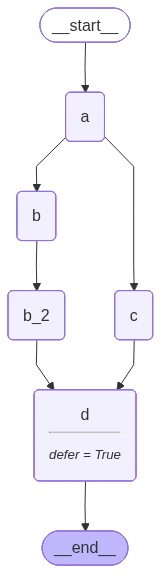

In [35]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))